Dimensions du dataset : (1466, 16)
Colonnes disponibles : ['player_id', 'name', 'position', 'age', 'country', 'Buts', 'xG', 'Succ_dribbles', 'Tacles', 'Assists', 'Passes_Reussies_Pct', 'club', 'league', 'market_value_raw', 'short_name', 'jersey_number']
Nombre de doublons identifiés et supprimés : 0


Dimensions du dataset après retrait des valeurs aberrantes : (1384, 16)

--- Statistiques Descriptives ---
          player_id          age         Buts           xG  Succ_dribbles  \
count  1.384000e+03  1384.000000  1384.000000  1384.000000    1384.000000   
mean   9.113165e+05    25.885116     1.680636     1.763439       9.371387   
std    4.132089e+05     4.259372     2.646276     2.459137      11.236661   
min    2.899000e+03    16.000000     0.000000     0.000000       0.000000   
25%    8.077402e+05    23.000000     0.000000     0.180000       1.000000   
50%    9.473120e+05    25.000000     1.000000     0.920000       6.000000   
75%    1.114914e+06    29.000000     2.000000     2.262500      13.000000   
max    2.311163e+06    40.000000    19.000000    17.560000      75.000000   

            Tacles      Assists  Passes_Reussies_Pct  market_value_raw  
count  1384.000000  1384.000000          1384.000000      1.384000e+03  
mean     21.911127     1.268064            79.882637 

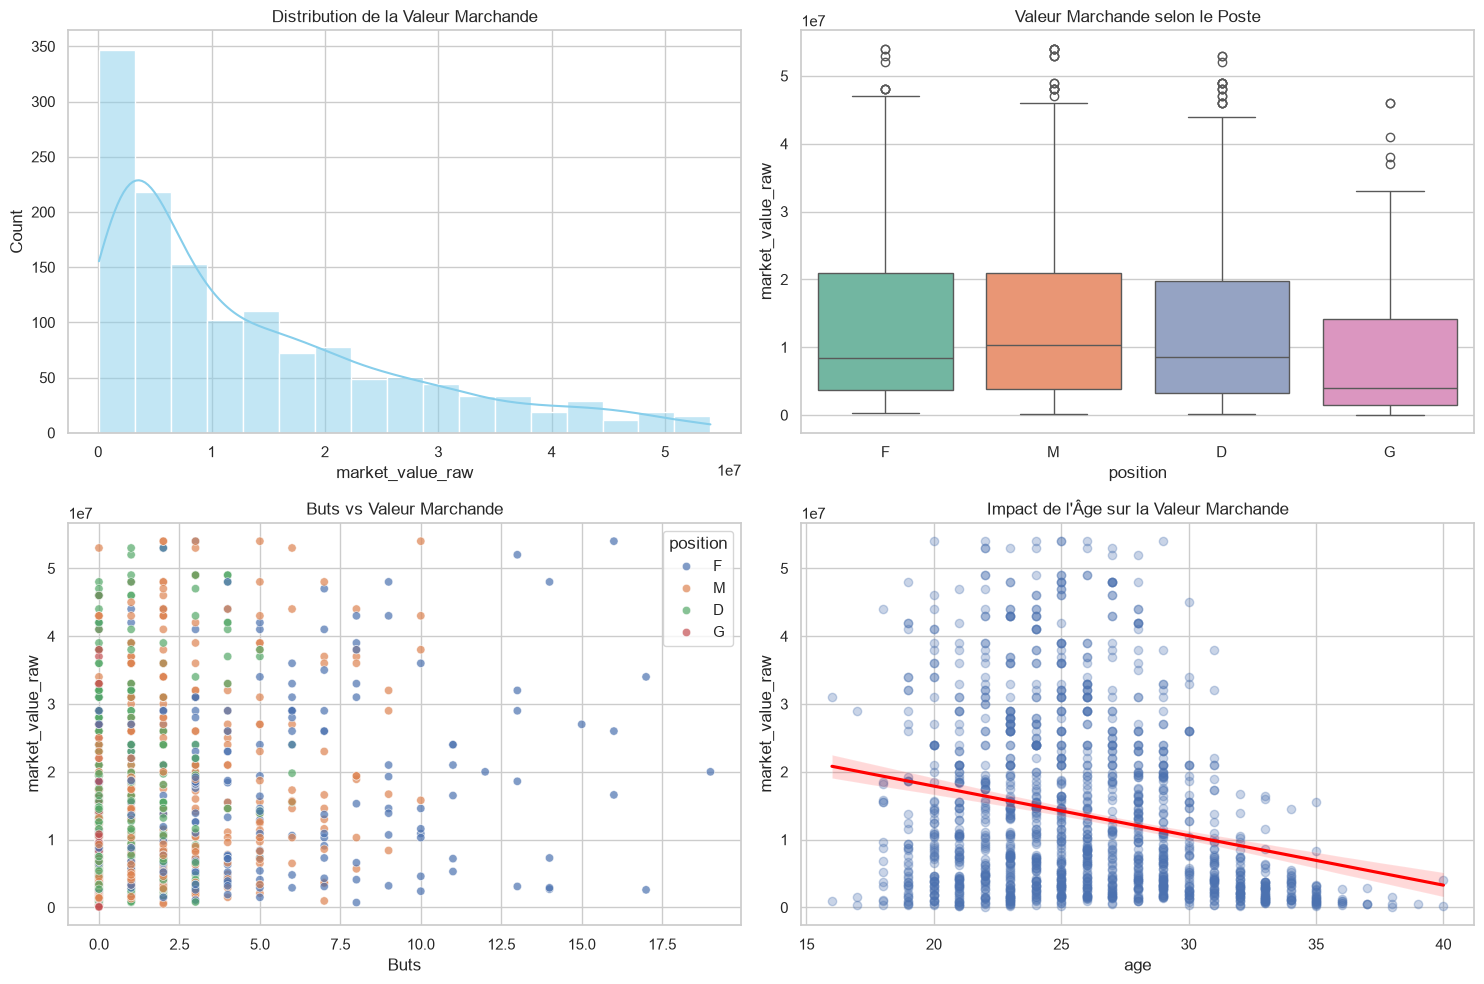

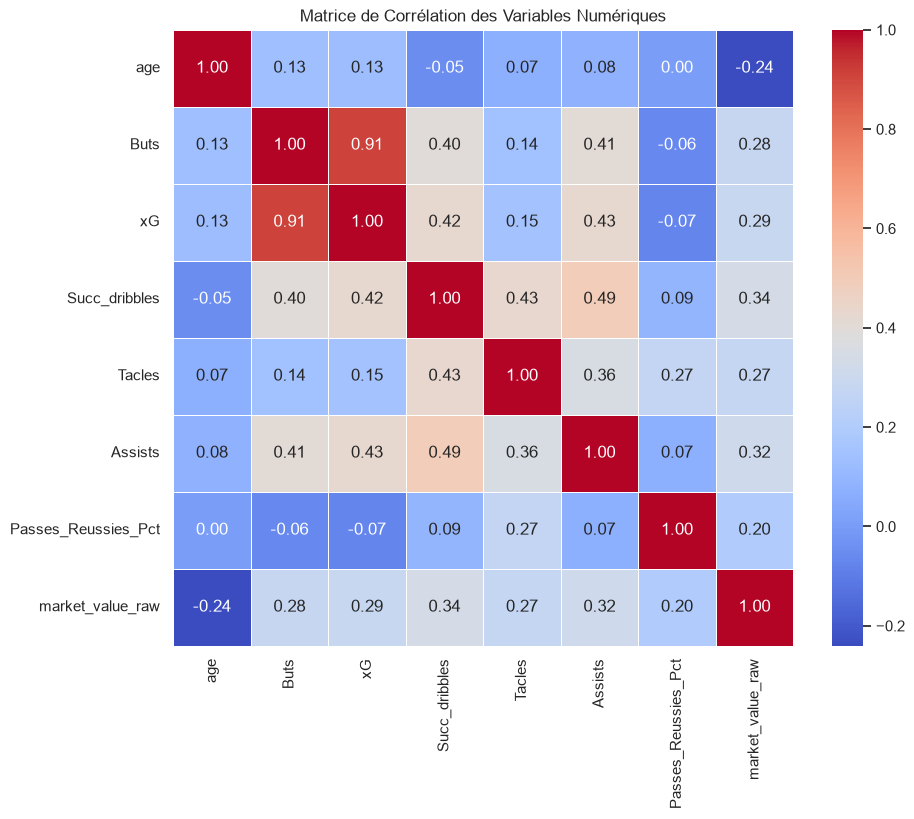


--- Répartition des Données ---
Jeu d'Entraînement (Train) : 1107 lignes (80%)
Jeu de Validation (Val)    : 138 lignes (10%)
Jeu de Test (Test)         : 139 lignes (10%)



--- Comparaison des Modèles (Évalués sur le jeu de Validation - 10%) ---
                              MAE          RMSE        R²
Régression Linéaire  6.095927e+06  8.189823e+06  0.434608
Ridge Regression     5.965739e+06  7.992775e+06  0.461488
Random Forest        5.211541e+06  7.774732e+06  0.490468
Gradient Boosting    5.199248e+06  7.326864e+06  0.547481

Optimisation du Random Forest via GridSearchCV...


Meilleurs hyperparamètres : {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 150}

--- Évaluation Définitive sur le Jeu de Test (10% derniers) ---
MAE  : 6622556.372
RMSE : 9303958.993
R²   : 0.437



Silhouette Score pour K=3 Clusters : 0.250

--- Caractéristiques Moyennes des Clusters ---
               age      Buts        xG  Succ_dribbles     Tacles   Assists  \
Cluster                                                                      
0        25.424318  0.531017  0.686191       3.465261  10.467742  0.372208   
1        26.332613  1.978402  2.024190      16.870410  41.866091  2.248380   
2        27.313043  8.539130  8.263739      20.573913  21.773913  3.600000   

         Passes_Reussies_Pct  market_value_raw  
Cluster                                         
0                  78.586079      1.003490e+07  
1                  83.285875      1.783411e+07  
2                  75.268087      2.148948e+07  

--- Statistiques Moyennes par Poste ---
                age      Buts        xG  Succ_dribbles     Tacles   Assists  \
position                                                                      
D         25.870044  0.781938  0.889317       6.570485  29.281938  0.8722

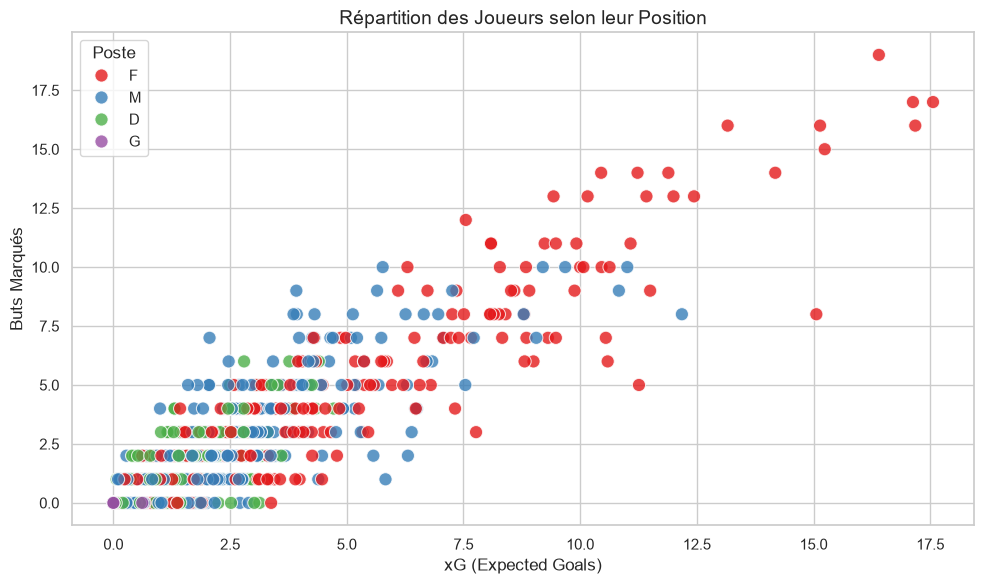


 Modèle sauvegardé avec succès dans le fichier 'modele_marche_joueur.pkl'

--- Prédiction d'Inférence ---
La valeur marchande prédite pour ce nouveau joueur est de : 40,560,666.67 M euro


In [1]:
# ==============================================================================
# IMPORTATION DES BIBLIOTHÈQUES
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modèles de Régression (Prédire la valeur marchande)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modèles de Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignorer les avertissements spécifiques de Scikit-Learn
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Configuration visuelle
sns.set_theme(style="whitegrid")
%matplotlib inline

# ==============================================================================
# A. CHARGEMENT DES DONNÉES
# ==============================================================================
df = pd.read_csv("dataset_final.csv")
print(f"Dimensions du dataset : {df.shape}")
print(f"Colonnes disponibles : {df.columns.tolist()}")

# ==============================================================================
# B. PRÉTRAITEMENT DES DONNÉES (Preprocessing)
# ==============================================================================

target_col = 'market_value_raw'

# Correction : S'assurer que la colonne cible est bien numérique (conversion en cas de texte/string)
if target_col in df.columns:
    df[target_col] = pd.to_numeric(df[target_col].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')

# 1. Gestion des valeurs manquantes et conversion des colonnes numériques
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)
if 'player_id' in num_cols:
    num_cols.remove('player_id')  # On exclut l'ID technique des features

imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Imputation spécifique pour la cible si des valeurs sont NaN après conversion
df[target_col] = df[target_col].fillna(df[target_col].median())

# 2. Suppression des doublons
doublons = df.duplicated().sum()
print(f"Nombre de doublons identifiés et supprimés : {doublons}")
df = df.drop_duplicates()

# 3. Traitement des valeurs aberrantes (Outliers) par la méthode de l'IQR sur la cible
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1
borne_inf = max(0, Q1 - 1.5 * IQR)
borne_sup = Q3 + 1.5 * IQR
df = df[(df[target_col] >= borne_inf) & (df[target_col] <= borne_sup)]
print(f"Dimensions du dataset après retrait des valeurs aberrantes : {df.shape}")

# ==============================================================================
# C. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# ==============================================================================

# 1. Statistiques Descriptives
print("\n--- Statistiques Descriptives ---")
print(df.describe())

# 2. Visualisations (Génération des graphiques)
plt.figure(figsize=(15, 10))

# Histogramme de la Valeur Marchande
plt.subplot(2, 2, 1)
sns.histplot(df[target_col], kde=True, color='skyblue')
plt.title("Distribution de la Valeur Marchande")

# Boxplot de la Valeur Marchande par Poste (avec hue et legend=False pour Seaborn récent)
plt.subplot(2, 2, 2)
sns.boxplot(x='position', y=target_col, hue='position', data=df, palette='Set2', legend=False)
plt.title("Valeur Marchande selon le Poste")

# Nuage de points : Buts vs Valeur Marchande
plt.subplot(2, 2, 3)
sns.scatterplot(x='Buts', y=target_col, hue='position', data=df, alpha=0.7)
plt.title("Buts vs Valeur Marchande")

# Relation entre l'Âge et la Valeur Marchande
plt.subplot(2, 2, 4)
sns.regplot(x='age', y=target_col, data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Impact de l'Âge sur la Valeur Marchande")

plt.tight_layout()
plt.show()

# 3. Matrice de Corrélation
plt.figure(figsize=(10, 8))
corr_matrix = df[num_cols + [target_col]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matrice de Corrélation des Variables Numériques")
plt.show()

# ==============================================================================
# D. MACHINE LEARNING : RÉGRESSION (Prédiction de la Valeur Marchande)
# ==============================================================================

# Séparation des caractéristiques (X) et de la cible (y)
X = df.drop(columns=['player_id', 'name', target_col])
y = df[target_col]

# Définition des colonnes catégoriques et numériques
categorical_cols = ['position', 'country', 'club', 'league']
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Création du pipeline de prétraitement pour la modélisation
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# ------------------------------------------------------------------------------
# DIVISION STRICTE EN 3 PHASES : TRAIN (80%), VALIDATION (10%), TEST (10%)
# ------------------------------------------------------------------------------
# Étape 1 : Isoler les 80% pour l'entraînement et 20% temporaire
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42)

# Étape 2 : Couper le bloc temporaire en deux parts égales de 10% chacun (Validation et Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"\n--- Répartition des Données ---")
print(f"Jeu d'Entraînement (Train) : {X_train.shape[0]} lignes ({len(X_train)/len(df)*100:.0f}%)")
print(f"Jeu de Validation (Val)    : {X_val.shape[0]} lignes ({len(X_val)/len(df)*100:.0f}%)")
print(f"Jeu de Test (Test)         : {X_test.shape[0]} lignes ({len(X_test)/len(df)*100:.0f}%)")

# Définition des algorithmes à comparer
models = {
    "Régression Linéaire": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# 1. ENTRAÎNEMENT (sur 80%) et ÉVALUATION (sur les 10% de validation)
results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    # Entraînement exclusif sur X_train (80%)
    pipeline.fit(X_train, y_train)
    
    # Évaluation sur X_val (10% de validation)
    y_pred_val = pipeline.predict(X_val)
    
    mae = mean_absolute_error(y_val, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2}

# Affichage des résultats de validation
df_results = pd.DataFrame(results).T
print("\n--- Comparaison des Modèles (Évalués sur le jeu de Validation - 10%) ---")
print(df_results)

# ------------------------------------------------------------------------------
# OPTIMISATION DES HYPERPARAMÈTRES (Random Forest)
# ------------------------------------------------------------------------------
print("\nOptimisation du Random Forest via GridSearchCV...")
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('rf', RandomForestRegressor(random_state=42))])

param_grid = {
    'rf__n_estimators': [50, 100, 150],
    'rf__max_depth': [10, 15, None],
    'rf__min_samples_split': [2, 5]
}

# GridSearchCV s'appuie sur le jeu d'entraînement (80%)
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")

# 2. TEST FINAL (sur les 10% de test strictement isolés)
y_pred_test = best_model.predict(X_test)
print("\n--- Évaluation Définitive sur le Jeu de Test (10% derniers) ---")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_test):.3f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f}")
print(f"R²   : {r2_score(y_test, y_pred_test):.3f}")

# ==============================================================================
# E. MACHINE LEARNING : CLUSTERING (Segmentation des Profils)
# ==============================================================================

# Choix des variables pour le clustering
features_clustering = ['age', 'Buts', 'xG', 'Succ_dribbles', 'Tacles', 'Assists', 'Passes_Reussies_Pct']
X_cluster = df[features_clustering]

# Standardisation des données de clustering
scaler_clust = StandardScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster)

# Utilisation de la méthode du coude (Elbow Method) pour déterminer le nombre de clusters
wcss = []
for i in range(2, 8):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

# Entraînement de K-Means avec K = 3 (Nombre optimal de profils de jeu)
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

# Calcul du score de silhouette
sil_score = silhouette_score(X_cluster_scaled, df['Cluster'])
print(f"\nSilhouette Score pour K=3 Clusters : {sil_score:.3f}")

# Interprétation des clusters
print("\n--- Caractéristiques Moyennes des Clusters ---")
print(df.groupby('Cluster')[features_clustering + [target_col]].mean())

# ==============================================================================
# ANALYSE : GROUPEMENT PAR POSITION
# ==============================================================================

features_analyse = ['age', 'Buts', 'xG', 'Succ_dribbles', 'Tacles', 'Assists', 'Passes_Reussies_Pct', target_col]

print("\n--- Statistiques Moyennes par Poste ---")
print(df.groupby('position')[features_analyse].mean())

df['Cluster_Position'] = df['position'].astype('category').cat.codes

# Affichage graphique selon la position
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='xG', 
    y='Buts', 
    hue='position', 
    palette='Set1', 
    data=df, 
    s=90, 
    alpha=0.8
)
plt.title("Répartition des Joueurs selon leur Position", fontsize=14)
plt.xlabel("xG (Expected Goals)", fontsize=12)
plt.ylabel("Buts Marqués", fontsize=12)
plt.legend(title="Poste", loc="upper left")
plt.tight_layout()
plt.show()

# Sauvegarde du modèle entraîné dans un fichier
joblib.dump(best_model, "modele_marche_joueur.pkl")
print("\n Modèle sauvegardé avec succès dans le fichier 'modele_marche_joueur.pkl'")

# ==============================================================================
# F. INFÉRENCE (Prédiction sur de nouvelles données)
# ==============================================================================

nouveau_joueur = pd.DataFrame([{
    "position": "F",
    "age": 24.0,
    "country": "England",
    "Buts": 20,
    "xG": 18.5,
    "Succ_dribbles": 40,
    "Tacles": 10,
    "Assists": 5,
    "Passes_Reussies_Pct": 82.0,
    "club": "bayern_munich",
    "league": "bundesliga"
}])

valeur_predite = best_model.predict(nouveau_joueur)[0]
print(f"\n--- Prédiction d'Inférence ---")
print(f"La valeur marchande prédite pour ce nouveau joueur est de : {valeur_predite:,.2f} M euro")